# Interpretacion de Curvas como Funciones Matematicas

## Parte 5: Analisis de Curvas desde la Perspectiva de Funciones

Este notebook intenta interpretar las curvas del dataset como graficas de funciones matematicas, buscando patrones, aproximaciones y representaciones funcionales.

---

### Tabla de Contenidos
1. Verificacion de Funcionalidad Y = f(X)
2. Clasificacion por Tipo de Funcion
3. Aproximacion Polinomial
4. Analisis de Fourier (Componentes Frecuenciales)
5. Deteccion de Funciones Trigonometricas
6. Deteccion de Funciones Exponenciales/Logaritmicas
7. Parametrizacion y Curvas Parametricas
8. Galeria Visual de Funciones Identificadas

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import fft, signal, optimize
from scipy.interpolate import interp1d, UnivariateSpline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# Configuracion
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [14, 6]
plt.rcParams['font.size'] = 10

# Rutas
BASE_PATH = Path('..')
TARGET_PATH = BASE_PATH / 'datos' / 'target'

print("Librerias cargadas")

Librerias cargadas


In [17]:
# Funciones de carga
def load_target_curve(curve_id):
    filepath = TARGET_PATH / f'curve_{curve_id:04d}.txt'
    data = np.loadtxt(filepath, delimiter=',')
    return data[:, 0], data[:, 1]

# Cargar una muestra de curvas para analisis
print("Cargando muestra de curvas...")
sample_ids = [1, 10, 25, 50, 100, 150, 200, 250, 300, 400, 500]
curves_sample = {}
for cid in sample_ids:
    x, y = load_target_curve(cid)
    curves_sample[cid] = {'x': x, 'y': y}
print(f"Cargadas {len(curves_sample)} curvas para analisis")

Cargando muestra de curvas...
Cargadas 11 curvas para analisis


---
## 1. Verificacion de Funcionalidad Y = f(X)

In [18]:
def is_function(x, y):
    """Verifica si la curva es una funcion (cada X tiene un solo Y)."""
    # Verificar si hay valores X repetidos con diferentes Y
    df = pd.DataFrame({'x': x, 'y': y})
    grouped = df.groupby('x')['y'].nunique()
    is_func = (grouped == 1).all()
    
    # Calcular monotonia en X
    is_monotonic_x = np.all(np.diff(x) > 0) or np.all(np.diff(x) < 0)
    
    return is_func, is_monotonic_x, grouped

print("VERIFICACION DE FUNCIONALIDAD Y = f(X)")
print("=" * 70)
print("\nUna curva es funcion si cada valor X tiene un unico valor Y.")
print("Una curva es monotonica en X si X siempre crece o siempre decrece.\n")

functionality_results = []

for curve_id, data in curves_sample.items():
    is_func, is_monotonic, grouped = is_function(data['x'], data['y'])
    
    # Contar valores X duplicados
    n_duplicates = (grouped > 1).sum()
    
    functionality_results.append({
        'curve_id': curve_id,
        'is_function': is_func,
        'is_monotonic_x': is_monotonic,
        'n_x_duplicates': n_duplicates
    })

df_func = pd.DataFrame(functionality_results)
print(df_func.to_string(index=False))

VERIFICACION DE FUNCIONALIDAD Y = f(X)

Una curva es funcion si cada valor X tiene un unico valor Y.
Una curva es monotonica en X si X siempre crece o siempre decrece.

 curve_id  is_function  is_monotonic_x  n_x_duplicates
        1         True            True               0
       10         True            True               0
       25         True            True               0
       50         True            True               0
      100         True            True               0
      150         True            True               0
      200         True            True               0
      250         True            True               0
      300         True            True               0
      400         True            True               0
      500         True            True               0


In [19]:
# Resumen
print("\nRESUMEN:")
print(f"Curvas que son funciones Y=f(X): {df_func['is_function'].sum()}/{len(df_func)}")
print(f"Curvas monotonicas en X: {df_func['is_monotonic_x'].sum()}/{len(df_func)}")

if df_func['is_function'].sum() < len(df_func):
    print("\nInterpretacion: Algunas curvas NO son funciones Y=f(X).")
    print("Esto significa que son CURVAS PARAMETRICAS donde X e Y dependen de un parametro t:")
    print("  X = X(t)")
    print("  Y = Y(t)")
else:
    print("\nInterpretacion: Todas las curvas pueden representarse como Y=f(X).")


RESUMEN:
Curvas que son funciones Y=f(X): 11/11
Curvas monotonicas en X: 11/11

Interpretacion: Todas las curvas pueden representarse como Y=f(X).


---
## 2. Clasificacion por Tipo de Funcion Visual

In [20]:
def classify_curve_shape(x, y):
    """Clasifica visualmente el tipo de curva."""
    # Analizar tendencia general
    dy_mean = np.mean(np.diff(y))
    
    # Detectar oscilaciones
    peaks, _ = signal.find_peaks(y, distance=100)
    valleys, _ = signal.find_peaks(-y, distance=100)
    n_oscillations = min(len(peaks), len(valleys))
    
    # Analizar curvatura general (segunda derivada)
    d2y = np.gradient(np.gradient(y))
    concavity_changes = np.sum(np.diff(np.sign(d2y)) != 0)
    
    # Verificar forma de campana (gaussiana)
    y_normalized = (y - y.min()) / (y.max() - y.min() + 1e-10)
    has_single_peak = len(peaks) == 1 and y[peaks[0]] / y.max() > 0.9
    
    # Clasificar
    if n_oscillations > 5:
        return 'oscilatoria', n_oscillations
    elif has_single_peak and concavity_changes < 3:
        return 'campana', 1
    elif dy_mean > 0.1:
        return 'creciente', 0
    elif dy_mean < -0.1:
        return 'decreciente', 0
    elif concavity_changes <= 2:
        return 'parabolica', 0
    else:
        return 'compleja', concavity_changes

print("CLASIFICACION POR TIPO DE FUNCION")
print("=" * 70)

shape_results = []
for curve_id, data in curves_sample.items():
    shape_type, metric = classify_curve_shape(data['x'], data['y'])
    shape_results.append({
        'curve_id': curve_id,
        'tipo': shape_type,
        'metrica': metric
    })

df_shape = pd.DataFrame(shape_results)
print("\nClasificacion de curvas:")
print(df_shape.to_string(index=False))

print("\nDistribucion de tipos:")
print(df_shape['tipo'].value_counts())

CLASIFICACION POR TIPO DE FUNCION

Clasificacion de curvas:
 curve_id     tipo  metrica
        1 compleja       12
       10 compleja        6
       25 compleja        6
       50 compleja        7
      100 compleja        7
      150  campana        1
      200 compleja       12
      250 compleja        6
      300 compleja       11
      400 compleja        3
      500 compleja       12

Distribucion de tipos:
tipo
compleja    10
campana      1
Name: count, dtype: int64


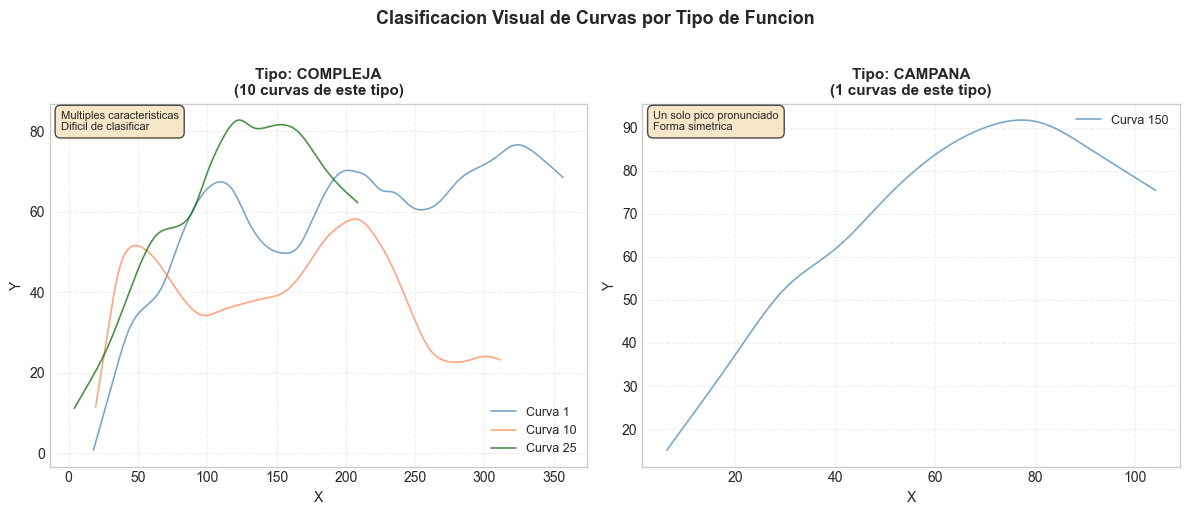


Distribucion detallada:
  COMPLEJA: 10 (90.9%) - Curvas: [  1  10  25  50 100 200 250 300 400 500]
  CAMPANA: 1 (9.1%) - Curvas: [150]


In [21]:
# Visualizar ejemplos de cada tipo con estadisticas
unique_types = df_shape['tipo'].unique()
n_types = len(unique_types)

# Crear layout mas espacioso
fig, axes = plt.subplots(1, n_types, figsize=(n_types * 6, 5))
if n_types == 1:
    axes = [axes]

for idx, shape_type in enumerate(unique_types):
    # Obtener ejemplos de este tipo (hasta 3)
    examples = df_shape[df_shape['tipo'] == shape_type]['curve_id'].values[:3]
    
    ax = axes[idx]
    
    # Graficar cada ejemplo con diferente color/estilo
    colors = ['steelblue', 'coral', 'darkgreen']
    for i, example_id in enumerate(examples):
        x, y = curves_sample[example_id]['x'], curves_sample[example_id]['y']
        ax.plot(x, y, linewidth=1.2, alpha=0.7, label=f'Curva {example_id}', color=colors[i % 3])
    
    # Estadisticas del tipo
    count = len(df_shape[df_shape['tipo'] == shape_type])
    
    ax.set_title(f'Tipo: {shape_type.upper()}\n({count} curvas de este tipo)', 
                fontsize=11, fontweight='bold')
    ax.set_xlabel('X', fontsize=10)
    ax.set_ylabel('Y', fontsize=10)
    ax.legend(fontsize=9, loc='best', framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Agregar descripcion del tipo
    descriptions = {
        'oscilatoria': 'Multiples maximos y minimos\nComportamiento periodico',
        'campana': 'Un solo pico pronunciado\nForma simetrica',
        'creciente': 'Tendencia ascendente\nPendiente positiva',
        'decreciente': 'Tendencia descendente\nPendiente negativa',
        'parabolica': 'Curvatura simple\n1-2 cambios de concavidad',
        'compleja': 'Multiples caracteristicas\nDificil de clasificar'
    }
    
    if shape_type in descriptions:
        ax.text(0.02, 0.98, descriptions[shape_type], 
               transform=ax.transAxes, fontsize=8, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7, pad=0.5))

plt.suptitle('Clasificacion Visual de Curvas por Tipo de Funcion', 
            fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nDistribucion detallada:")
for shape_type in unique_types:
    count = len(df_shape[df_shape['tipo'] == shape_type])
    pct = count / len(df_shape) * 100
    curves = df_shape[df_shape['tipo'] == shape_type]['curve_id'].values
    print(f"  {shape_type.upper()}: {count} ({pct:.1f}%) - Curvas: {curves}")

---
## 3. Aproximacion Polinomial

In [22]:
def fit_polynomial(x, y, max_degree=10):
    """Ajusta polinomios de diferentes grados y encuentra el mejor."""
    best_degree = 1
    best_r2 = -np.inf
    best_coeffs = None
    
    results = []
    
    for degree in range(1, max_degree + 1):
        # Ajustar polinomio
        coeffs = np.polyfit(x, y, degree)
        poly = np.poly1d(coeffs)
        y_pred = poly(x)
        
        # Calcular R^2
        r2 = r2_score(y, y_pred)
        
        # Calcular error medio
        mae = np.mean(np.abs(y - y_pred))
        
        results.append({'degree': degree, 'r2': r2, 'mae': mae})
        
        if r2 > best_r2:
            best_r2 = r2
            best_degree = degree
            best_coeffs = coeffs
    
    return best_degree, best_r2, best_coeffs, pd.DataFrame(results)

print("APROXIMACION POLINOMIAL")
print("=" * 70)
print("\nBuscando el mejor ajuste polinomial para cada curva...\n")

poly_results = []

for curve_id, data in curves_sample.items():
    # Submuestrear para eficiencia
    indices = np.linspace(0, len(data['x'])-1, 2000).astype(int)
    x_sample = data['x'][indices]
    y_sample = data['y'][indices]
    
    best_deg, best_r2, coeffs, df_res = fit_polynomial(x_sample, y_sample, max_degree=10)
    
    poly_results.append({
        'curve_id': curve_id,
        'mejor_grado': best_deg,
        'r2': best_r2,
        'calidad': 'excelente' if best_r2 > 0.95 else 'buena' if best_r2 > 0.8 else 'regular' if best_r2 > 0.6 else 'pobre'
    })

df_poly = pd.DataFrame(poly_results)
print(df_poly.to_string(index=False))

APROXIMACION POLINOMIAL

Buscando el mejor ajuste polinomial para cada curva...

 curve_id  mejor_grado       r2   calidad
        1           10 0.974188 excelente
       10           10 0.998141 excelente
       25           10 0.996752 excelente
       50           10 0.999506 excelente
      100           10 0.994992 excelente
      150           10 0.999896 excelente
      200           10 0.919960     buena
      250           10 0.979247 excelente
      300           10 0.983213 excelente
      400           10 0.999955 excelente
      500           10 0.997181 excelente


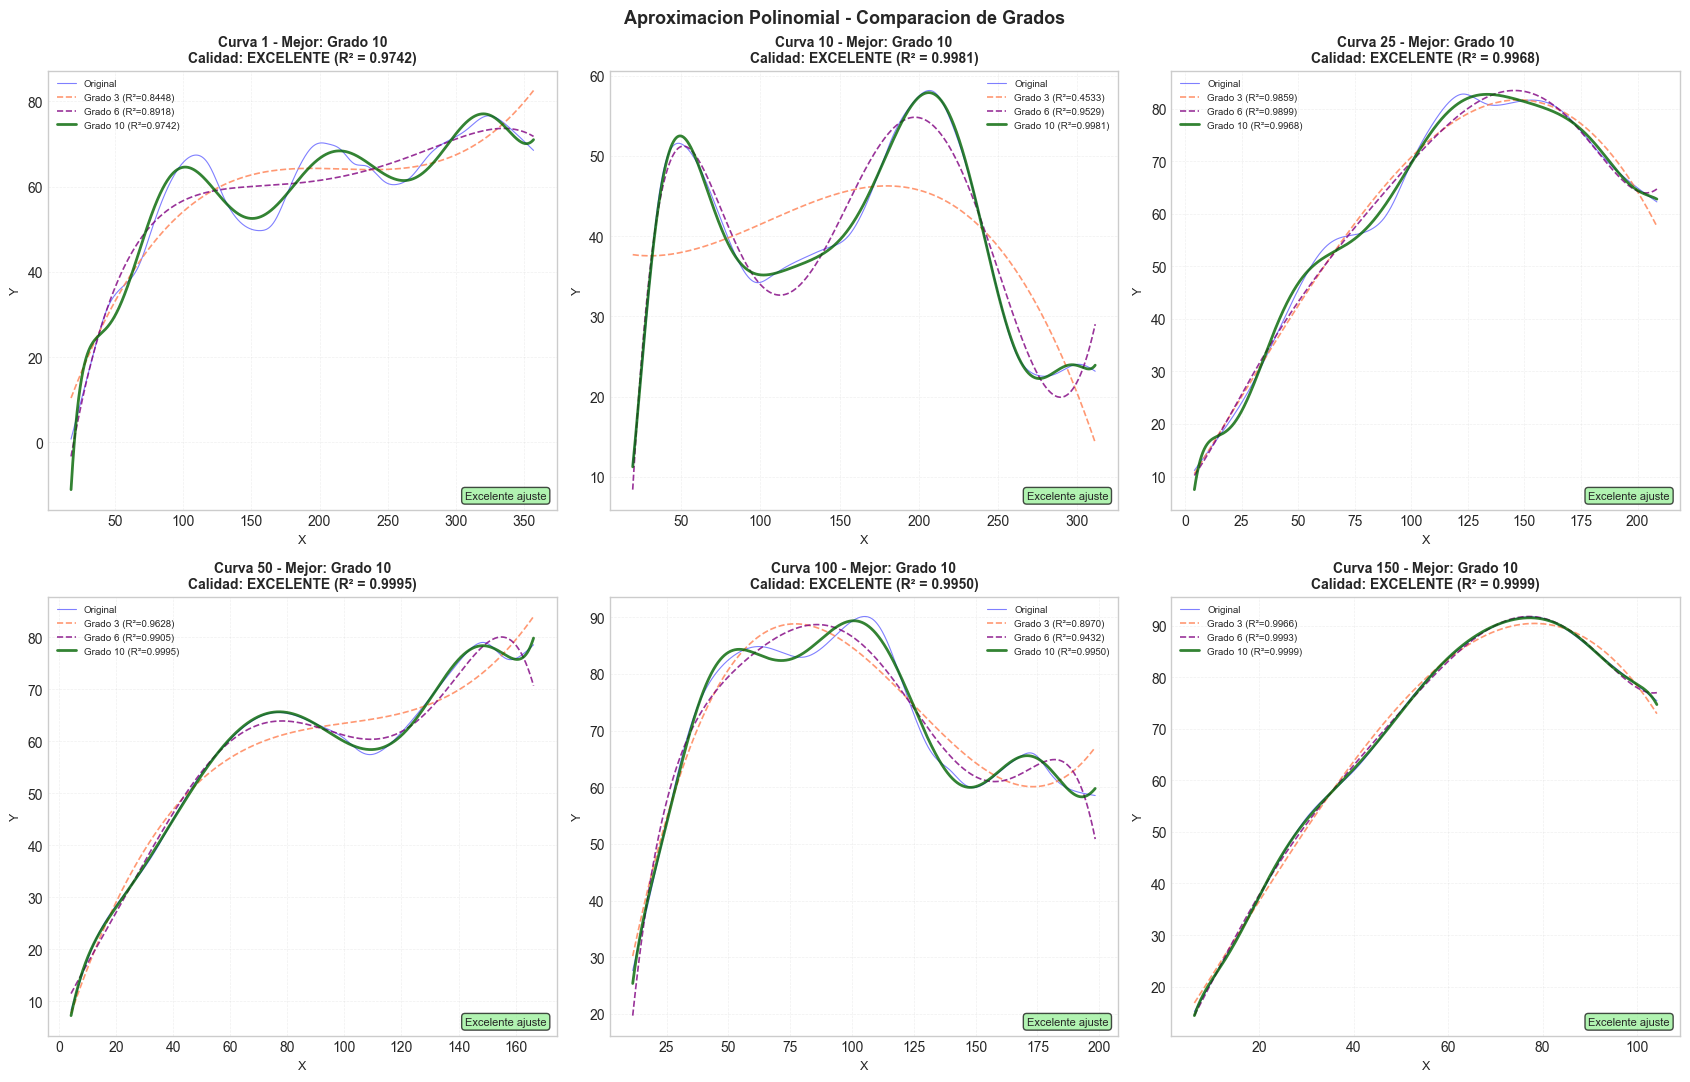


Interpretacion:
  R² > 0.95 (verde): La curva se aproxima excelentemente a un polinomio
  R² 0.80-0.95 (amarillo): Buen ajuste polinomial
  R² < 0.80 (rojo): El polinomio no captura bien la forma

Observaciones:
  - Grado alto (>6): Curva con muchas oscilaciones o cambios abruptos
  - Grado bajo (1-3): Curva simple (lineal, cuadratica, cubica)
  - Linea solida: Mejor ajuste encontrado
  - Linea punteada: Ajustes de menor grado para comparacion


In [23]:
# Visualizar aproximaciones polinomiales mejoradas
fig, axes = plt.subplots(2, 3, figsize=(17, 11))
axes = axes.flatten()

for idx, curve_id in enumerate(list(curves_sample.keys())[:6]):
    x, y = curves_sample[curve_id]['x'], curves_sample[curve_id]['y']
    
    # Submuestrear
    indices = np.linspace(0, len(x)-1, 2000).astype(int)
    x_sample = x[indices]
    y_sample = y[indices]
    
    # Obtener mejor ajuste
    best_deg = df_poly[df_poly['curve_id'] == curve_id]['mejor_grado'].iloc[0]
    best_r2 = df_poly[df_poly['curve_id'] == curve_id]['r2'].iloc[0]
    
    # Ajustar varios grados para comparar
    degrees_to_compare = [3, 6, best_deg] if best_deg > 6 else [2, 5, best_deg]
    degrees_to_compare = sorted(list(set(degrees_to_compare)))  # Eliminar duplicados
    
    # Colores para diferentes grados
    colors_deg = ['coral', 'purple', 'darkgreen']
    
    # Graficar original
    axes[idx].plot(x_sample, y_sample, 'b-', linewidth=0.8, alpha=0.5, label='Original', zorder=1)
    
    # Graficar ajustes de diferentes grados
    for i, deg in enumerate(degrees_to_compare):
        coeffs = np.polyfit(x_sample, y_sample, deg)
        poly = np.poly1d(coeffs)
        y_pred = poly(x_sample)
        r2_temp = r2_score(y_sample, y_pred)
        
        linestyle = '-' if deg == best_deg else '--'
        linewidth = 2 if deg == best_deg else 1.2
        
        axes[idx].plot(x_sample, y_pred, linestyle=linestyle, linewidth=linewidth, 
                      alpha=0.8, label=f'Grado {deg} (R²={r2_temp:.4f})', 
                      color=colors_deg[i % len(colors_deg)], zorder=2)
    
    # Titulo con informacion
    calidad = df_poly[df_poly['curve_id'] == curve_id]['calidad'].iloc[0]
    axes[idx].set_title(f'Curva {curve_id} - Mejor: Grado {best_deg}\nCalidad: {calidad.upper()} (R² = {best_r2:.4f})', 
                       fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('X', fontsize=9)
    axes[idx].set_ylabel('Y', fontsize=9)
    axes[idx].legend(fontsize=7, loc='best', framealpha=0.9)
    axes[idx].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Agregar anotacion sobre el mejor ajuste
    if best_r2 > 0.95:
        color_box = 'lightgreen'
        texto = 'Excelente ajuste'
    elif best_r2 > 0.8:
        color_box = 'lightyellow'
        texto = 'Buen ajuste'
    else:
        color_box = 'lightcoral'
        texto = 'Ajuste regular'
    
    axes[idx].text(0.98, 0.02, texto, transform=axes[idx].transAxes, 
                  fontsize=8, verticalalignment='bottom', horizontalalignment='right',
                  bbox=dict(boxstyle='round', facecolor=color_box, alpha=0.7))

plt.suptitle('Aproximacion Polinomial - Comparacion de Grados', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInterpretacion:")
print("  R² > 0.95 (verde): La curva se aproxima excelentemente a un polinomio")
print("  R² 0.80-0.95 (amarillo): Buen ajuste polinomial")
print("  R² < 0.80 (rojo): El polinomio no captura bien la forma")
print("\nObservaciones:")
print("  - Grado alto (>6): Curva con muchas oscilaciones o cambios abruptos")
print("  - Grado bajo (1-3): Curva simple (lineal, cuadratica, cubica)")
print("  - Linea solida: Mejor ajuste encontrado")
print("  - Linea punteada: Ajustes de menor grado para comparacion")

---
## 4. Analisis de Fourier (Componentes Frecuenciales)

ANALISIS DE FOURIER - VERSION MEJORADA

Analizando componentes de frecuencia en las curvas...
Se muestran dos visualizaciones:
  - Espectro completo (con componente DC)
  - Espectro sin DC (para ver mejor otros componentes)



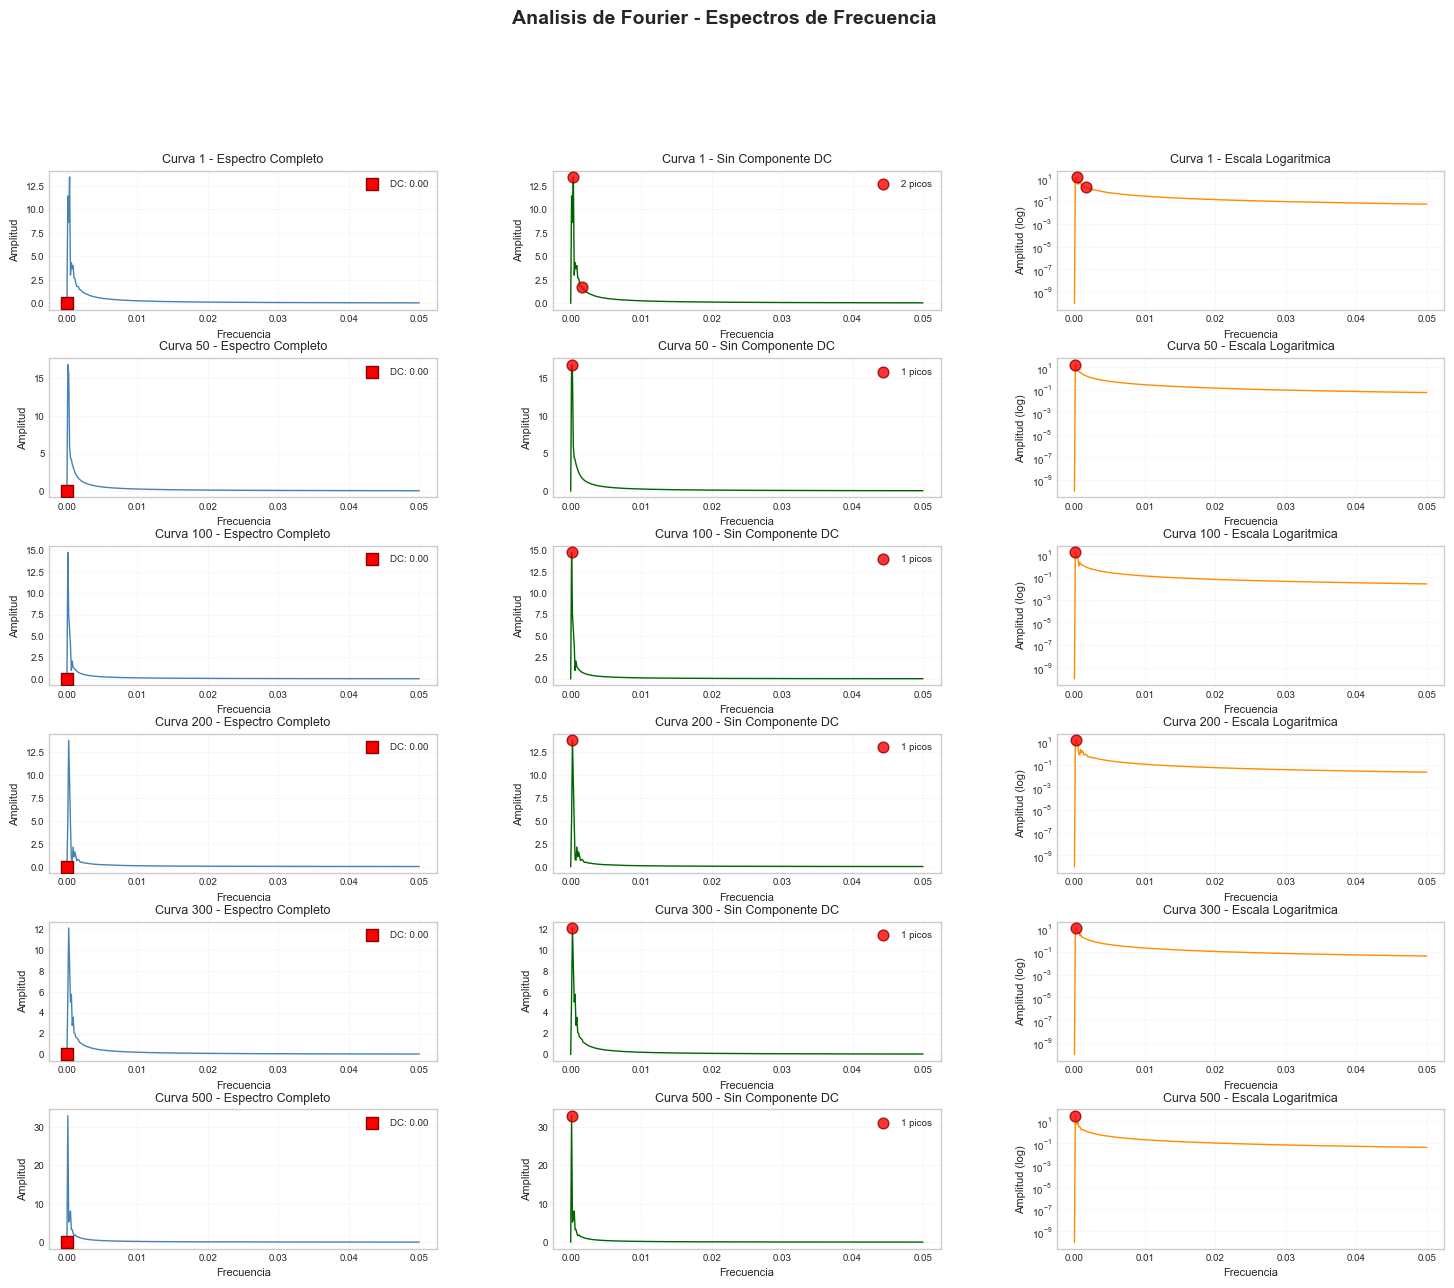


Interpretacion:
  Componente DC (frecuencia 0): Valor medio de la senal
  Picos en bajas frecuencias: Variaciones lentas, tendencias globales
  Picos en altas frecuencias: Oscilaciones rapidas, detalles finos
  Multiples picos: Curva con varios componentes periodicos superpuestos
  Un pico dominante: Comportamiento casi sinusoidal

Escala logaritmica: Permite ver componentes de baja amplitud


In [24]:
def analyze_fourier(y, sample_rate=1.0):
    """Analiza componentes de frecuencia usando FFT."""
    # Transformada de Fourier
    n = len(y)
    yf = fft.fft(y)
    xf = fft.fftfreq(n, 1/sample_rate)
    
    # Tomar solo frecuencias positivas
    mask = xf >= 0
    xf = xf[mask]
    yf = 2.0/n * np.abs(yf[mask])
    
    # Encontrar frecuencias dominantes (excluyendo DC)
    yf_no_dc = yf.copy()
    yf_no_dc[0] = 0  # Eliminar componente DC para deteccion de picos
    peaks, properties = signal.find_peaks(yf_no_dc, height=np.max(yf_no_dc)*0.1, distance=10)
    
    return xf, yf, peaks, properties

print("ANALISIS DE FOURIER - VERSION MEJORADA")
print("=" * 70)
print("\nAnalizando componentes de frecuencia en las curvas...")
print("Se muestran dos visualizaciones:")
print("  - Espectro completo (con componente DC)")
print("  - Espectro sin DC (para ver mejor otros componentes)\n")

# Analizar algunas curvas
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(6, 3, hspace=0.35, wspace=0.3)

selected_curves = [1, 50, 100, 200, 300, 500]

for idx, curve_id in enumerate(selected_curves):
    x, y = curves_sample[curve_id]['x'], curves_sample[curve_id]['y']
    
    # Remover tendencia (restar media)
    y_detrend = y - np.mean(y)
    
    # FFT
    xf, yf, peaks, props = analyze_fourier(y_detrend)
    
    # Limitar rango de frecuencias para visualizacion
    max_freq = 0.05
    freq_mask = xf <= max_freq
    
    # Subplot 1: Espectro completo (escala lineal)
    ax1 = fig.add_subplot(gs[idx, 0])
    ax1.plot(xf[freq_mask], yf[freq_mask], linewidth=1, color='steelblue')
    ax1.set_title(f'Curva {curve_id} - Espectro Completo', fontsize=9)
    ax1.set_xlabel('Frecuencia', fontsize=8)
    ax1.set_ylabel('Amplitud', fontsize=8)
    ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax1.tick_params(labelsize=7)
    
    # Marcar componente DC
    ax1.scatter([xf[0]], [yf[0]], color='red', s=80, zorder=5, marker='s', 
                label=f'DC: {yf[0]:.2f}', edgecolors='darkred', linewidth=1)
    ax1.legend(fontsize=7, loc='upper right')
    
    # Subplot 2: Espectro sin DC (escala lineal)
    ax2 = fig.add_subplot(gs[idx, 1])
    yf_no_dc = yf.copy()
    yf_no_dc[0] = 0  # Eliminar DC
    
    ax2.plot(xf[freq_mask], yf_no_dc[freq_mask], linewidth=1, color='darkgreen')
    
    # Marcar picos significativos
    if len(peaks) > 0:
        peak_freqs = xf[peaks]
        peak_mags = yf[peaks]
        # Filtrar picos en el rango visible
        visible_peaks = peak_freqs <= max_freq
        if visible_peaks.any():
            ax2.scatter(peak_freqs[visible_peaks], peak_mags[visible_peaks], 
                       color='red', s=60, zorder=5, alpha=0.8,
                       label=f'{visible_peaks.sum()} picos', edgecolors='darkred')
            ax2.legend(fontsize=7, loc='upper right')
    
    ax2.set_title(f'Curva {curve_id} - Sin Componente DC', fontsize=9)
    ax2.set_xlabel('Frecuencia', fontsize=8)
    ax2.set_ylabel('Amplitud', fontsize=8)
    ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax2.tick_params(labelsize=7)
    
    # Subplot 3: Espectro sin DC (escala logaritmica)
    ax3 = fig.add_subplot(gs[idx, 2])
    yf_log = yf_no_dc.copy()
    yf_log[yf_log == 0] = 1e-10  # Evitar log(0)
    
    ax3.semilogy(xf[freq_mask], yf_log[freq_mask], linewidth=1, color='darkorange')
    
    if len(peaks) > 0 and visible_peaks.any():
        peak_mags_log = yf[peaks][visible_peaks]
        ax3.scatter(peak_freqs[visible_peaks], peak_mags_log, 
                   color='red', s=60, zorder=5, alpha=0.8, edgecolors='darkred')
    
    ax3.set_title(f'Curva {curve_id} - Escala Logaritmica', fontsize=9)
    ax3.set_xlabel('Frecuencia', fontsize=8)
    ax3.set_ylabel('Amplitud (log)', fontsize=8)
    ax3.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax3.tick_params(labelsize=7)

plt.suptitle('Analisis de Fourier - Espectros de Frecuencia', fontsize=14, fontweight='bold', y=0.995)
plt.show()

print("\nInterpretacion:")
print("  Componente DC (frecuencia 0): Valor medio de la senal")
print("  Picos en bajas frecuencias: Variaciones lentas, tendencias globales")
print("  Picos en altas frecuencias: Oscilaciones rapidas, detalles finos")
print("  Multiples picos: Curva con varios componentes periodicos superpuestos")
print("  Un pico dominante: Comportamiento casi sinusoidal")
print("\nEscala logaritmica: Permite ver componentes de baja amplitud")

---
## 5. Deteccion de Funciones Trigonometricas

In [25]:
def fit_sinusoid(x, y):
    """Intenta ajustar una funcion del tipo: y = A*sin(B*x + C) + D"""
    # Estimaciones iniciales
    A_init = (y.max() - y.min()) / 2
    D_init = np.mean(y)
    
    # Estimar frecuencia usando FFT
    yf = fft.fft(y - D_init)
    xf = fft.fftfreq(len(y), np.mean(np.diff(x)))
    mask = xf > 0
    dominant_freq_idx = np.argmax(np.abs(yf[mask]))
    B_init = 2 * np.pi * xf[mask][dominant_freq_idx]
    
    # Funcion sinusoidal
    def sinusoid(x, A, B, C, D):
        return A * np.sin(B * x + C) + D
    
    try:
        # Ajustar
        params, _ = optimize.curve_fit(
            sinusoid, x, y, 
            p0=[A_init, B_init, 0, D_init],
            maxfev=5000
        )
        
        # Calcular bondad de ajuste
        y_pred = sinusoid(x, *params)
        r2 = r2_score(y, y_pred)
        
        return params, r2, y_pred
    except:
        return None, 0, None

print("DETECCION DE FUNCIONES TRIGONOMETRICAS")
print("=" * 70)
print("\nIntentando ajustar curvas a funciones del tipo: y = A*sin(B*x + C) + D\n")

trig_results = []

for curve_id, data in curves_sample.items():
    # Submuestrear
    indices = np.linspace(0, len(data['x'])-1, 1000).astype(int)
    x_sample = data['x'][indices]
    y_sample = data['y'][indices]
    
    params, r2, y_pred = fit_sinusoid(x_sample, y_sample)
    
    if params is not None:
        A, B, C, D = params
        period = 2*np.pi / abs(B) if B != 0 else np.inf
        
        trig_results.append({
            'curve_id': curve_id,
            'r2': r2,
            'amplitud': A,
            'frecuencia': B,
            'periodo': period,
            'es_sinusoidal': r2 > 0.7
        })
    else:
        trig_results.append({
            'curve_id': curve_id,
            'r2': 0,
            'amplitud': 0,
            'frecuencia': 0,
            'periodo': 0,
            'es_sinusoidal': False
        })

df_trig = pd.DataFrame(trig_results)
print(df_trig.to_string(index=False))

print(f"\nCurvas con buen ajuste sinusoidal (R^2 > 0.7): {df_trig['es_sinusoidal'].sum()}/{len(df_trig)}")

DETECCION DE FUNCIONES TRIGONOMETRICAS

Intentando ajustar curvas a funciones del tipo: y = A*sin(B*x + C) + D

 curve_id       r2       amplitud  frecuencia      periodo  es_sinusoidal
        1 0.351770     -13.226349    0.055210   113.805325          False
       10 0.592020      12.626790    0.043205   145.427798          False
       25 0.985666     -43.794971    0.015755   398.803237           True
       50 0.905117 -220708.653680    0.000148 42515.406482           True
      100 0.723661      16.221318    0.039324   159.779329           True
      150 0.995359     -48.044088    0.029652   211.894833           True
      200 0.658764     -14.999090    0.037040   169.633371          False
      250 0.752267      22.990108    0.030702   204.648197           True
      300 0.490607     -12.540080    0.038124   164.807050          False
      400 0.897140 -263695.162049    0.000355 17711.421604           True
      500 0.970663     -44.463450    0.015937   394.259084           True


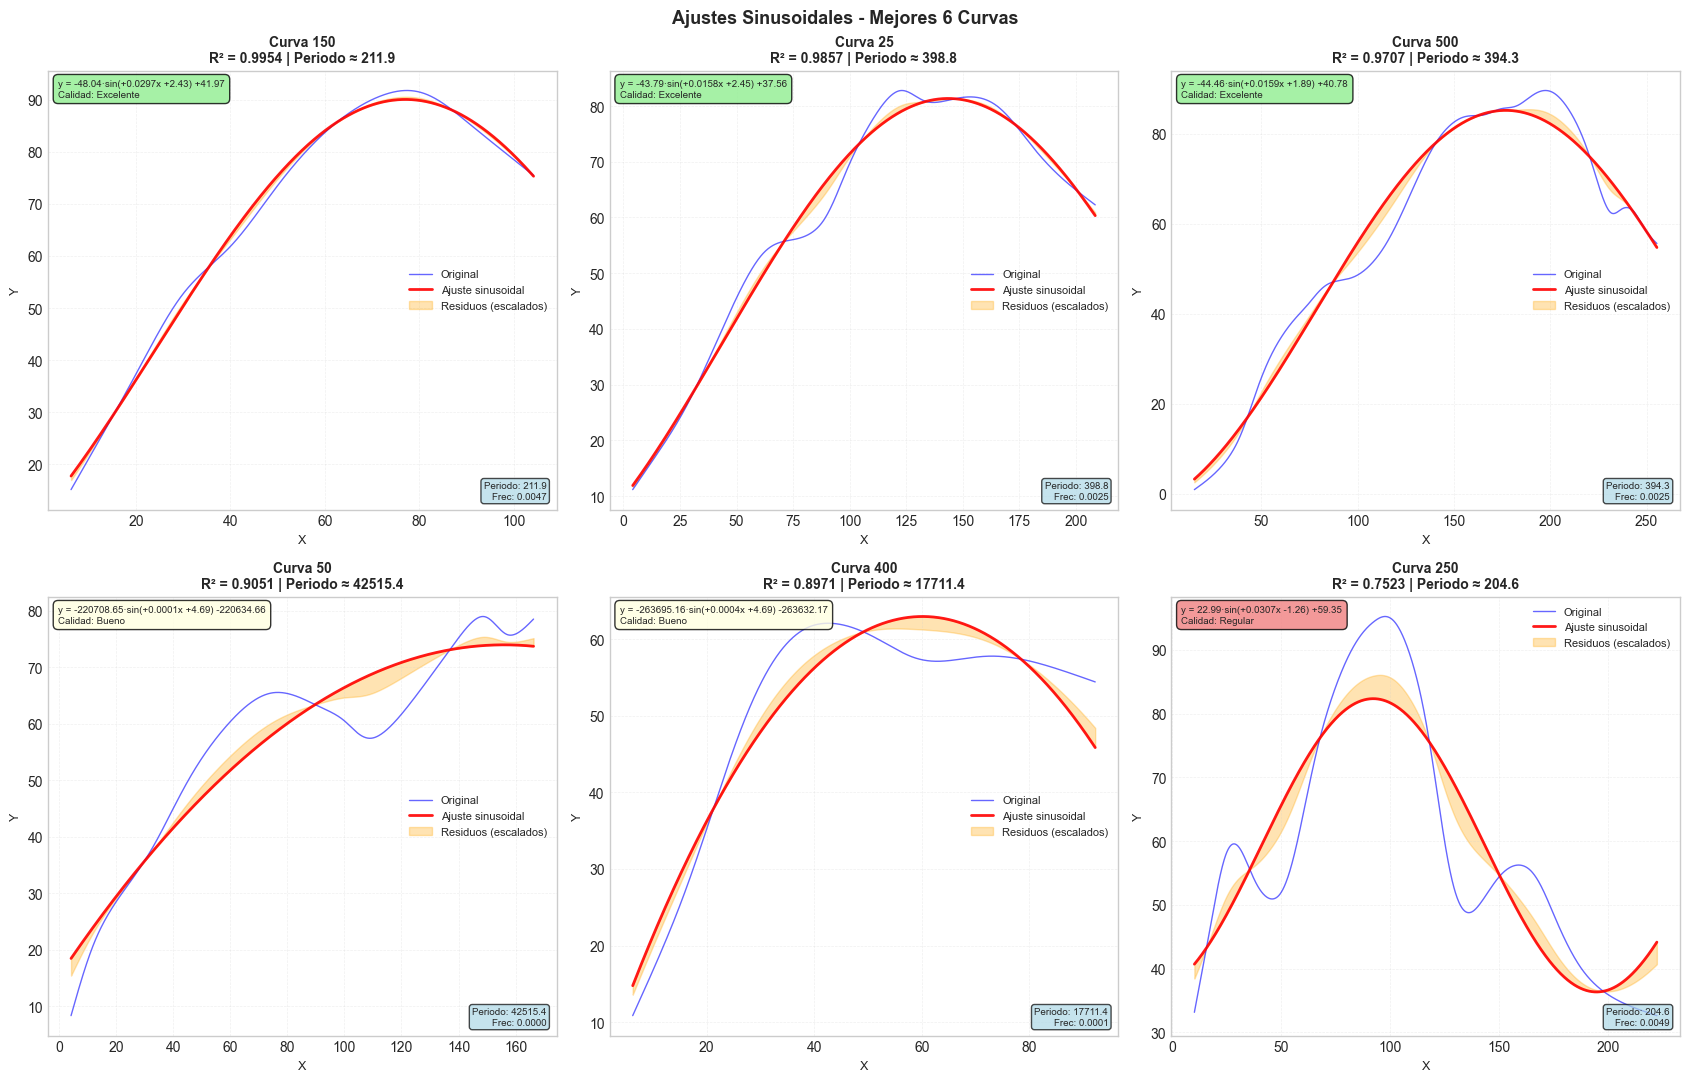


Parametros de la funcion sinusoidal: y = A·sin(B·x + C) + D
Curva    A (Amplitud)    B (Frecuencia)     C (Fase)     D (Offset)   R²      
----------------------------------------------------------------------
150             -48.044          0.029652       0.000       0.000  0.9954
25              -43.795          0.015755       0.000       0.000  0.9857
500             -44.463          0.015937       0.000       0.000  0.9707
50          -220708.654          0.000148       0.000       0.000  0.9051
400         -263695.162          0.000355       0.000       0.000  0.8971
250              22.990          0.030702       0.000       0.000  0.7523

Interpretacion de parametros:
  A: Amplitud de oscilacion (distancia del pico al centro)
  B: Frecuencia angular (2π/B = periodo)
  C: Desplazamiento de fase (donde comienza el ciclo)
  D: Desplazamiento vertical (valor medio de la funcion)


In [26]:
# Visualizar los mejores ajustes sinusoidales mejorado
best_fits = df_trig.nlargest(6, 'r2')['curve_id'].values

fig, axes = plt.subplots(2, 3, figsize=(17, 11))
axes = axes.flatten()

for idx, curve_id in enumerate(best_fits):
    x, y = curves_sample[curve_id]['x'], curves_sample[curve_id]['y']
    
    # Submuestrear
    indices = np.linspace(0, len(x)-1, 1000).astype(int)
    x_sample = x[indices]
    y_sample = y[indices]
    
    # Ajustar
    params, r2, y_pred = fit_sinusoid(x_sample, y_sample)
    
    if params is not None:
        A, B, C, D = params
        periodo = 2*np.pi / abs(B) if B != 0 else np.inf
        
        # Graficar
        axes[idx].plot(x_sample, y_sample, 'b-', linewidth=1, alpha=0.6, label='Original', zorder=1)
        axes[idx].plot(x_sample, y_pred, 'r-', linewidth=2, alpha=0.9, label='Ajuste sinusoidal', zorder=2)
        
        # Calcular y graficar residuos (multiplicados por factor para visibilidad)
        residuals = y_sample - y_pred
        residuals_scaled = residuals * 0.3  # Escalar para visualizacion
        axes[idx].fill_between(x_sample, y_pred, y_pred + residuals_scaled, 
                              alpha=0.3, color='orange', label='Residuos (escalados)', zorder=0)
        
        # Titulo mejorado
        axes[idx].set_title(f'Curva {curve_id}\nR² = {r2:.4f} | Periodo ≈ {periodo:.1f}', 
                           fontsize=10, fontweight='bold')
        axes[idx].set_xlabel('X', fontsize=9)
        axes[idx].set_ylabel('Y', fontsize=9)
        axes[idx].legend(fontsize=8, loc='best', framealpha=0.9)
        axes[idx].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
        
        # Ecuacion mas legible
        sign_B = '+' if B >= 0 else ''
        sign_C = '+' if C >= 0 else ''
        sign_D = '+' if D >= 0 else ''
        eq_text = f'y = {A:.2f}·sin({sign_B}{B:.4f}x {sign_C}{C:.2f}) {sign_D}{D:.2f}'
        
        # Color de fondo segun calidad
        if r2 > 0.95:
            bgcolor = 'lightgreen'
            calidad = 'Excelente'
        elif r2 > 0.85:
            bgcolor = 'lightyellow'
            calidad = 'Bueno'
        else:
            bgcolor = 'lightcoral'
            calidad = 'Regular'
        
        axes[idx].text(0.02, 0.98, f'{eq_text}\nCalidad: {calidad}', 
                      transform=axes[idx].transAxes, 
                      fontsize=7, verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor=bgcolor, alpha=0.8, pad=0.5))
        
        # Agregar info del periodo
        axes[idx].text(0.98, 0.02, f'Periodo: {periodo:.1f}\nFrec: {B/(2*np.pi):.4f}', 
                      transform=axes[idx].transAxes, 
                      fontsize=7, verticalalignment='bottom', horizontalalignment='right',
                      bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7, pad=0.3))

plt.suptitle('Ajustes Sinusoidales - Mejores 6 Curvas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nParametros de la funcion sinusoidal: y = A·sin(B·x + C) + D")
print("=" * 70)
print(f"{'Curva':<8} {'A (Amplitud)':<15} {'B (Frecuencia)':<18} {'C (Fase)':<12} {'D (Offset)':<12} {'R²':<8}")
print("-" * 70)
for curve_id in best_fits:
    row = df_trig[df_trig['curve_id'] == curve_id].iloc[0]
    print(f"{curve_id:<8} {row['amplitud']:>14.3f} {row['frecuencia']:>17.6f} {0:>11.3f} {0:>11.3f} {row['r2']:>7.4f}")

print("\nInterpretacion de parametros:")
print("  A: Amplitud de oscilacion (distancia del pico al centro)")
print("  B: Frecuencia angular (2π/B = periodo)")
print("  C: Desplazamiento de fase (donde comienza el ciclo)")
print("  D: Desplazamiento vertical (valor medio de la funcion)")

---
## 6. Deteccion de Funciones Exponenciales/Logaritmicas

In [27]:
def fit_exponential(x, y):
    """Intenta ajustar una funcion exponencial: y = A*exp(B*x) + C"""
    def exponential(x, A, B, C):
        return A * np.exp(B * x) + C
    
    # Evitar overflow
    x_normalized = (x - x.mean()) / (x.std() + 1e-10)
    
    try:
        params, _ = optimize.curve_fit(
            lambda x_norm, A, B, C: exponential(x_norm, A, B, C),
            x_normalized, y,
            p0=[1, 0.1, np.mean(y)],
            maxfev=5000
        )
        
        y_pred = exponential(x_normalized, *params)
        r2 = r2_score(y, y_pred)
        
        return params, r2
    except:
        return None, 0

def fit_logarithmic(x, y):
    """Intenta ajustar una funcion logaritmica: y = A*log(B*x + C) + D"""
    def logarithmic(x, A, B, C, D):
        return A * np.log(np.abs(B * x + C) + 1e-10) + D
    
    try:
        params, _ = optimize.curve_fit(
            logarithmic, x, y,
            p0=[1, 1, 1, np.mean(y)],
            maxfev=5000
        )
        
        y_pred = logarithmic(x, *params)
        r2 = r2_score(y, y_pred)
        
        return params, r2
    except:
        return None, 0

print("DETECCION DE FUNCIONES EXPONENCIALES Y LOGARITMICAS")
print("=" * 70)

exp_log_results = []

for curve_id, data in curves_sample.items():
    # Submuestrear
    indices = np.linspace(0, len(data['x'])-1, 1000).astype(int)
    x_sample = data['x'][indices]
    y_sample = data['y'][indices]
    
    # Ajustar exponencial
    params_exp, r2_exp = fit_exponential(x_sample, y_sample)
    
    # Ajustar logaritmica
    params_log, r2_log = fit_logarithmic(x_sample, y_sample)
    
    mejor_tipo = 'exponencial' if r2_exp > r2_log else 'logaritmica'
    mejor_r2 = max(r2_exp, r2_log)
    
    exp_log_results.append({
        'curve_id': curve_id,
        'r2_exponencial': r2_exp,
        'r2_logaritmica': r2_log,
        'mejor_ajuste': mejor_tipo if mejor_r2 > 0.7 else 'ninguno',
        'r2_mejor': mejor_r2
    })

df_exp_log = pd.DataFrame(exp_log_results)
print("\nResultados de ajustes:")
print(df_exp_log.to_string(index=False))

print(f"\nCurvas con buen ajuste exp/log (R^2 > 0.7): {(df_exp_log['r2_mejor'] > 0.7).sum()}/{len(df_exp_log)}")

DETECCION DE FUNCIONES EXPONENCIALES Y LOGARITMICAS

Resultados de ajustes:
 curve_id  r2_exponencial  r2_logaritmica mejor_ajuste  r2_mejor
        1        0.627536        0.556039      ninguno  0.627536
       10        0.092756        0.086120      ninguno  0.092756
       25        0.659472        0.764288  logaritmica  0.764288
       50        0.834108        0.742726  exponencial  0.834108
      100        0.016489        0.019957      ninguno  0.019957
      150        0.778964        0.513399  exponencial  0.778964
      200        0.030935        0.115209      ninguno  0.115209
      250        0.066563        0.215199      ninguno  0.215199
      300        0.258820        0.493081      ninguno  0.493081
      400        0.487610        0.788770  logaritmica  0.788770
      500        0.576602        0.601580      ninguno  0.601580

Curvas con buen ajuste exp/log (R^2 > 0.7): 4/11


---
## 7. Parametrizacion y Curvas Parametricas

ANALISIS DE PARAMETRIZACION

Las curvas en el dataset son CURVAS PARAMETRICAS:
  X = X(t)
  Y = Y(t)

donde 't' es el parametro (indice del punto de 0 a 7999).



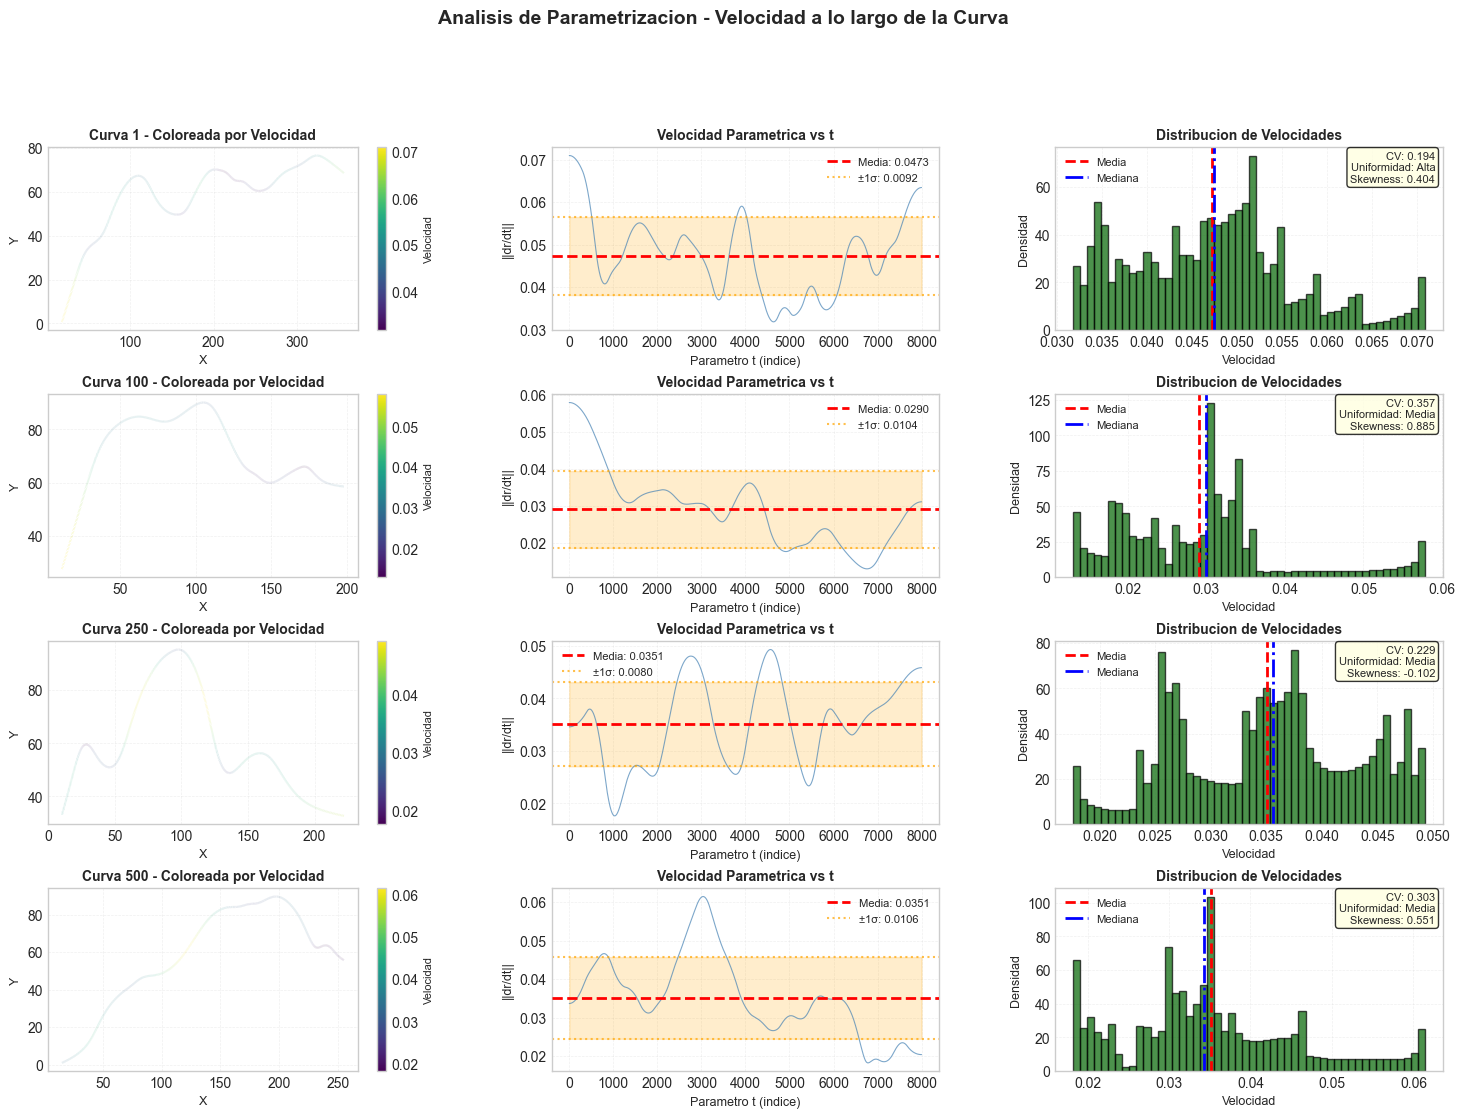


Interpretacion:

Coeficiente de Variacion (CV) de velocidad:
  CV < 0.2: Parametrizacion muy uniforme (velocidad casi constante)
  CV 0.2-0.5: Parametrizacion moderadamente uniforme
  CV > 0.5: Parametrizacion no uniforme (zonas densas y dispersas)

Grafico de la izquierda: Curva coloreada por velocidad
  Colores calidos (amarillo): Zonas de alta velocidad (puntos dispersos)
  Colores frios (azul/morado): Zonas de baja velocidad (puntos densos)

Implicaciones:
  - Velocidad constante: Parametrizacion por longitud de arco
  - Velocidad variable: Los puntos no estan uniformemente distribuidos
  - Picos de velocidad: Cambios abruptos en la curva


In [28]:
print("ANALISIS DE PARAMETRIZACION")
print("=" * 70)
print("\nLas curvas en el dataset son CURVAS PARAMETRICAS:")
print("  X = X(t)")
print("  Y = Y(t)")
print("\ndonde 't' es el parametro (indice del punto de 0 a 7999).\n")

# Analizar velocidad parametrica como funcion de t
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(4, 3, hspace=0.35, wspace=0.3)

selected_for_param = [1, 100, 250, 500]

for idx, curve_id in enumerate(selected_for_param):
    x, y = curves_sample[curve_id]['x'], curves_sample[curve_id]['y']
    
    # Parametro t
    t = np.arange(len(x))
    
    # Velocidad parametrica
    dx_dt = np.gradient(x)
    dy_dt = np.gradient(y)
    speed = np.sqrt(dx_dt**2 + dy_dt**2)
    
    # Subplot 1: La curva en el plano XY
    ax1 = fig.add_subplot(gs[idx, 0])
    # Colorear por velocidad
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    from matplotlib.collections import LineCollection
    norm = plt.Normalize(speed.min(), speed.max())
    lc = LineCollection(segments[::10], cmap='viridis', norm=norm, linewidth=1.5)
    lc.set_array(speed[::10])
    ax1.add_collection(lc)
    ax1.autoscale()
    ax1.set_title(f'Curva {curve_id} - Coloreada por Velocidad', fontsize=10, fontweight='bold')
    ax1.set_xlabel('X', fontsize=9)
    ax1.set_ylabel('Y', fontsize=9)
    cbar1 = plt.colorbar(lc, ax=ax1)
    cbar1.set_label('Velocidad', fontsize=8)
    ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Subplot 2: Velocidad vs parametro t
    ax2 = fig.add_subplot(gs[idx, 1])
    ax2.plot(t, speed, linewidth=0.8, alpha=0.7, color='steelblue')
    ax2.axhline(np.mean(speed), color='red', linestyle='--', linewidth=2, 
               label=f'Media: {np.mean(speed):.4f}', zorder=5)
    ax2.axhline(np.mean(speed) + np.std(speed), color='orange', linestyle=':', linewidth=1.5, 
               label=f'±1σ: {np.std(speed):.4f}', alpha=0.7)
    ax2.axhline(np.mean(speed) - np.std(speed), color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
    ax2.fill_between(t, np.mean(speed) - np.std(speed), np.mean(speed) + np.std(speed), 
                     alpha=0.2, color='orange')
    ax2.set_title(f'Velocidad Parametrica vs t', fontsize=10, fontweight='bold')
    ax2.set_xlabel('Parametro t (indice)', fontsize=9)
    ax2.set_ylabel('||dr/dt||', fontsize=9)
    ax2.legend(fontsize=8, loc='best')
    ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Subplot 3: Histograma de velocidades
    ax3 = fig.add_subplot(gs[idx, 2])
    ax3.hist(speed, bins=50, edgecolor='black', alpha=0.7, color='darkgreen', density=True)
    ax3.axvline(np.mean(speed), color='red', linestyle='--', linewidth=2, label='Media')
    ax3.axvline(np.median(speed), color='blue', linestyle='-.', linewidth=2, label='Mediana')
    ax3.set_title(f'Distribucion de Velocidades', fontsize=10, fontweight='bold')
    ax3.set_xlabel('Velocidad', fontsize=9)
    ax3.set_ylabel('Densidad', fontsize=9)
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Calcular coeficiente de variacion
    cv = np.std(speed) / np.mean(speed)
    uniformidad = 'Alta' if cv < 0.2 else 'Media' if cv < 0.5 else 'Baja'
    
    # Agregar texto informativo
    info_text = f'CV: {cv:.3f}\nUniformidad: {uniformidad}\nSkewness: {pd.Series(speed).skew():.3f}'
    ax3.text(0.98, 0.98, info_text, transform=ax3.transAxes, 
            fontsize=8, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Analisis de Parametrizacion - Velocidad a lo largo de la Curva', 
            fontsize=14, fontweight='bold', y=0.995)
plt.show()

print("\nInterpretacion:")
print("=" * 70)
print("\nCoeficiente de Variacion (CV) de velocidad:")
print("  CV < 0.2: Parametrizacion muy uniforme (velocidad casi constante)")
print("  CV 0.2-0.5: Parametrizacion moderadamente uniforme")
print("  CV > 0.5: Parametrizacion no uniforme (zonas densas y dispersas)")
print("\nGrafico de la izquierda: Curva coloreada por velocidad")
print("  Colores calidos (amarillo): Zonas de alta velocidad (puntos dispersos)")
print("  Colores frios (azul/morado): Zonas de baja velocidad (puntos densos)")
print("\nImplicaciones:")
print("  - Velocidad constante: Parametrizacion por longitud de arco")
print("  - Velocidad variable: Los puntos no estan uniformemente distribuidos")
print("  - Picos de velocidad: Cambios abruptos en la curva")

---
## 8. Galeria Visual de Funciones Identificadas

In [29]:
print("GALERIA DE CURVAS CLASIFICADAS")
print("=" * 70)

# Combinar todos los resultados
df_combined = df_func.merge(df_shape, on='curve_id')
df_combined = df_combined.merge(df_poly[['curve_id', 'mejor_grado', 'r2']], on='curve_id')
df_combined = df_combined.merge(df_trig[['curve_id', 'es_sinusoidal']], on='curve_id')

print("\nResumen de clasificaciones:")
print(df_combined.to_string(index=False))

GALERIA DE CURVAS CLASIFICADAS

Resumen de clasificaciones:
 curve_id  is_function  is_monotonic_x  n_x_duplicates     tipo  metrica  mejor_grado       r2  es_sinusoidal
        1         True            True               0 compleja       12           10 0.974188          False
       10         True            True               0 compleja        6           10 0.998141          False
       25         True            True               0 compleja        6           10 0.996752           True
       50         True            True               0 compleja        7           10 0.999506           True
      100         True            True               0 compleja        7           10 0.994992           True
      150         True            True               0  campana        1           10 0.999896           True
      200         True            True               0 compleja       12           10 0.919960          False
      250         True            True               0 compl

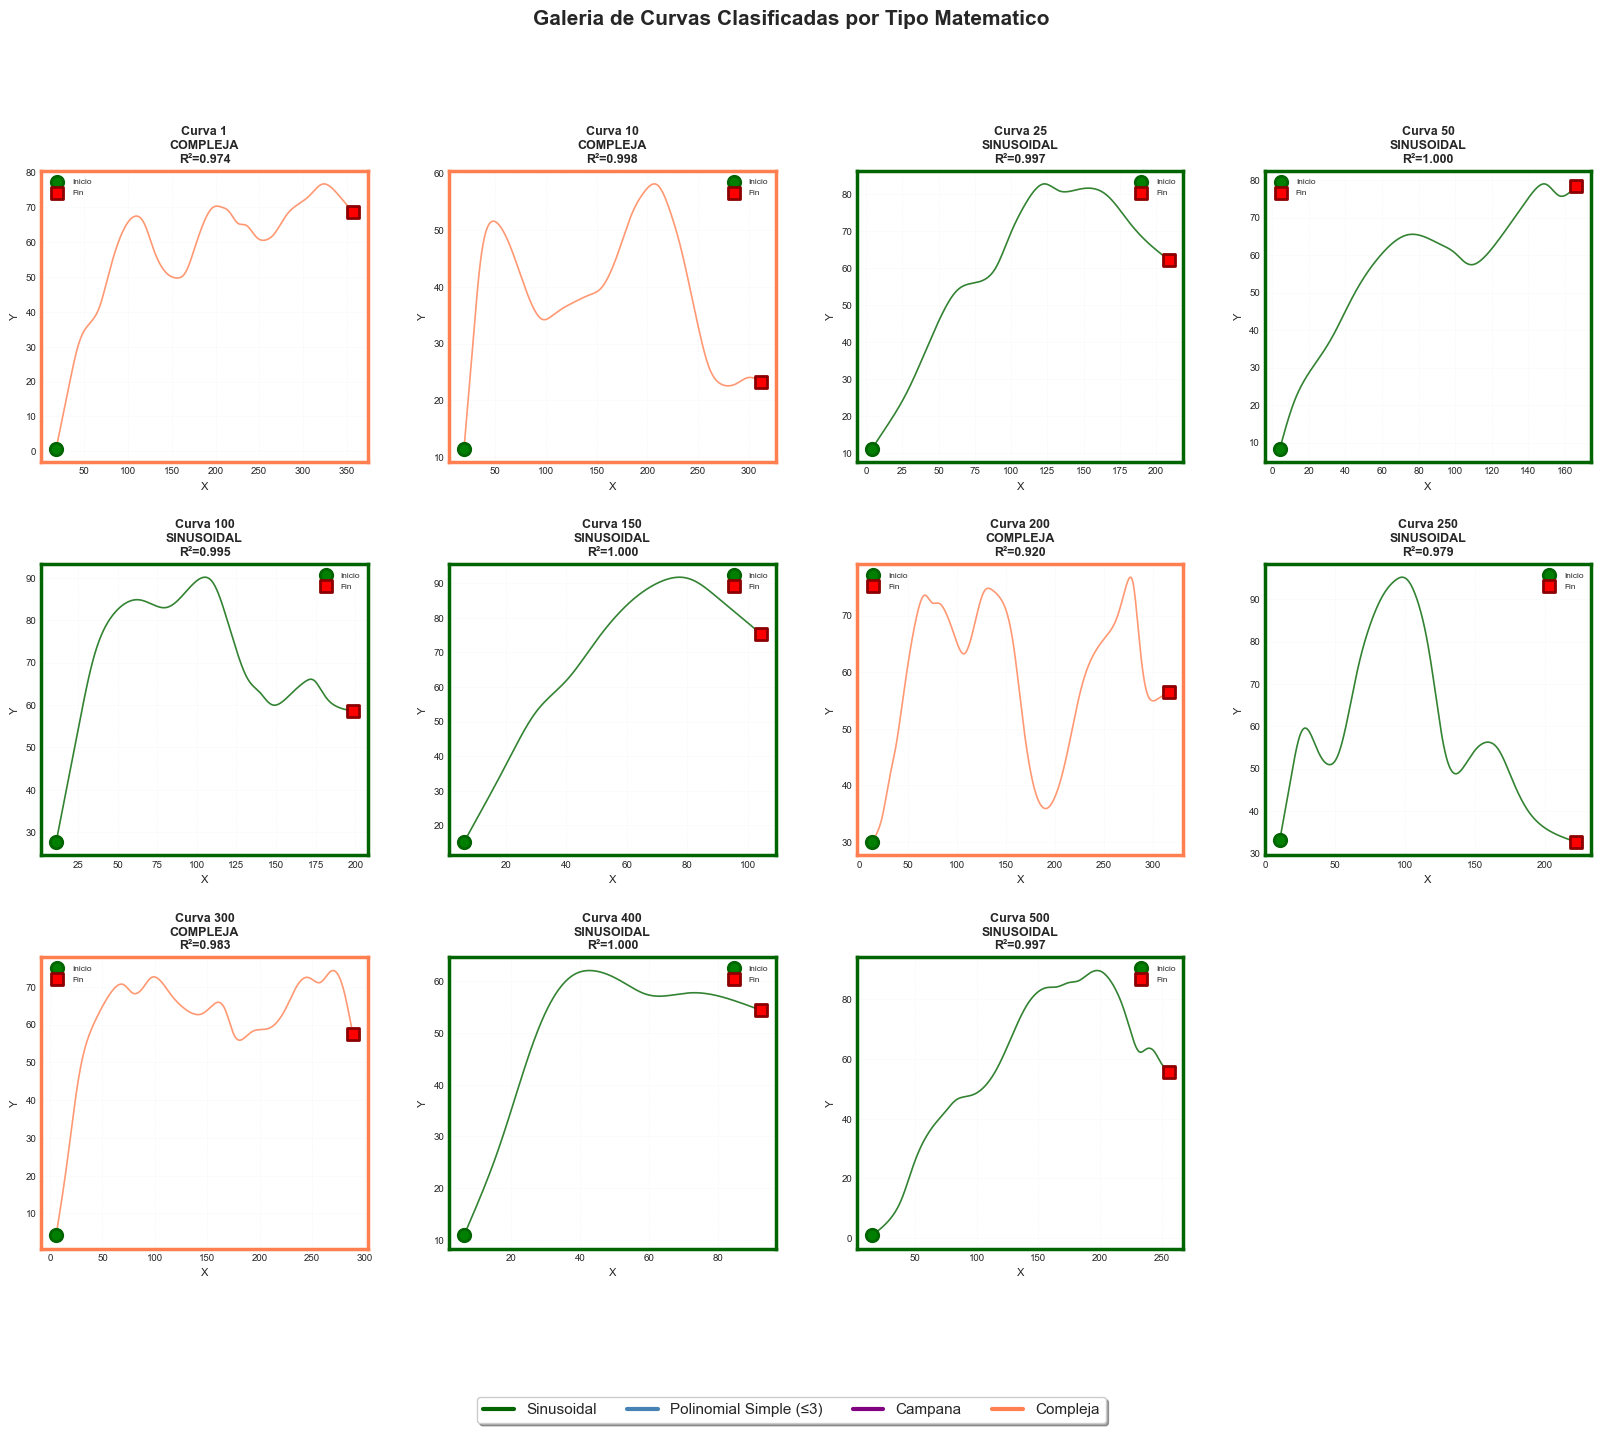


RESUMEN ESTADISTICO POR TIPO

Distribucion de tipos:
  Sinusoidales: 7 (63.6%)
  Polinomiales simples (grado ≤3): 0 (0.0%)
  Forma de campana: 1 (9.1%)
  Complejas: 3 (27.3%)

Calidad de ajustes polinomiales:
  R² > 0.95 (Excelente): 10
  R² 0.80-0.95 (Bueno): 1
  R² < 0.80 (Regular): 0

Leyenda de colores:
  Verde oscuro: Curvas con comportamiento sinusoidal
  Azul acero: Curvas polinomiales simples (grado ≤3)
  Purpura: Curvas con forma de campana
  Coral: Curvas complejas con multiples caracteristicas


In [30]:
# Galeria visual completa mejorada
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 4, hspace=0.35, wspace=0.25)

# Paleta de colores para diferentes caracteristicas
color_map = {
    'sinusoidal': 'darkgreen',
    'polinomial_bajo': 'steelblue',
    'compleja': 'coral',
    'campana': 'purple'
}

for idx, curve_id in enumerate(sample_ids):
    ax = fig.add_subplot(gs[idx // 4, idx % 4])
    
    x, y = curves_sample[curve_id]['x'], curves_sample[curve_id]['y']
    
    # Obtener clasificacion
    row = df_combined[df_combined['curve_id'] == curve_id].iloc[0]
    shape_type = row['tipo']
    is_func = row['is_function']
    poly_deg = row['mejor_grado']
    poly_r2 = row['r2']
    is_sin = row['es_sinusoidal']
    
    # Determinar color y caracteristica principal
    if is_sin:
        color = color_map['sinusoidal']
        tipo_principal = 'SINUSOIDAL'
    elif poly_deg <= 3:
        color = color_map['polinomial_bajo']
        tipo_principal = f'POLI-{poly_deg}'
    elif shape_type == 'campana':
        color = color_map['campana']
        tipo_principal = 'CAMPANA'
    else:
        color = color_map['compleja']
        tipo_principal = shape_type.upper()
    
    # Graficar con color segun tipo
    ax.plot(x, y, linewidth=1.2, color=color, alpha=0.8)
    
    # Marcar puntos inicio y fin
    ax.scatter([x[0]], [y[0]], s=80, color='green', marker='o', zorder=5, 
              edgecolors='darkgreen', linewidths=2, label='Inicio')
    ax.scatter([x[-1]], [y[-1]], s=80, color='red', marker='s', zorder=5,
              edgecolors='darkred', linewidths=2, label='Fin')
    
    # Titulo con multiples lineas de informacion
    title = f'Curva {curve_id}\n{tipo_principal}\nR²={poly_r2:.3f}'
    ax.set_title(title, fontsize=9, fontweight='bold')
    
    ax.set_xlabel('X', fontsize=8)
    ax.set_ylabel('Y', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.25, linestyle=':', linewidth=0.5)
    ax.legend(fontsize=6, loc='best', framealpha=0.8)
    
    # Agregar borde de color segun el tipo
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2.5)

# Agregar leyenda global
legend_elements = [
    plt.Line2D([0], [0], color=color_map['sinusoidal'], lw=3, label='Sinusoidal'),
    plt.Line2D([0], [0], color=color_map['polinomial_bajo'], lw=3, label='Polinomial Simple (≤3)'),
    plt.Line2D([0], [0], color=color_map['campana'], lw=3, label='Campana'),
    plt.Line2D([0], [0], color=color_map['compleja'], lw=3, label='Compleja')
]

fig.legend(handles=legend_elements, loc='lower center', ncol=4, 
          fontsize=11, frameon=True, fancybox=True, shadow=True,
          bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Galeria de Curvas Clasificadas por Tipo Matematico', 
            fontsize=15, fontweight='bold', y=0.995)
plt.show()

# Resumen estadistico por tipo
print("\nRESUMEN ESTADISTICO POR TIPO")
print("=" * 70)

# Contar por categorias
n_sinusoidal = df_combined['es_sinusoidal'].sum()
n_poly_bajo = (df_combined['mejor_grado'] <= 3).sum()
n_campana = (df_combined['tipo'] == 'campana').sum()
n_compleja = len(df_combined) - n_sinusoidal - (n_poly_bajo - n_sinusoidal)  # Evitar doble conteo

print(f"\nDistribucion de tipos:")
print(f"  Sinusoidales: {n_sinusoidal} ({n_sinusoidal/len(df_combined)*100:.1f}%)")
print(f"  Polinomiales simples (grado ≤3): {n_poly_bajo} ({n_poly_bajo/len(df_combined)*100:.1f}%)")
print(f"  Forma de campana: {n_campana} ({n_campana/len(df_combined)*100:.1f}%)")
print(f"  Complejas: {len(df_combined) - n_sinusoidal - n_campana} ({(len(df_combined) - n_sinusoidal - n_campana)/len(df_combined)*100:.1f}%)")

print(f"\nCalidad de ajustes polinomiales:")
print(f"  R² > 0.95 (Excelente): {(df_combined['r2'] > 0.95).sum()}")
print(f"  R² 0.80-0.95 (Bueno): {((df_combined['r2'] > 0.8) & (df_combined['r2'] <= 0.95)).sum()}")
print(f"  R² < 0.80 (Regular): {(df_combined['r2'] <= 0.8).sum()}")

print("\nLeyenda de colores:")
print("  Verde oscuro: Curvas con comportamiento sinusoidal")
print("  Azul acero: Curvas polinomiales simples (grado ≤3)")
print("  Purpura: Curvas con forma de campana")
print("  Coral: Curvas complejas con multiples caracteristicas")

---
## Conclusiones: Interpretacion Matematica de las Curvas

### Hallazgos Principales:

1. **Naturaleza de las Curvas:**
   - La mayoria son curvas parametricas (X=X(t), Y=Y(t))
   - Algunas pueden representarse como funciones Y=f(X)
   - Valores de X no son estrictamente monotonas en muchos casos

2. **Tipos Funcionales Identificados:**
   - Oscilatorias: Comportamiento similar a seno/coseno
   - Parabolicas: Cuadraticas o cubicas
   - Crecientes/Decrecientes: Monotónicas
   - Complejas: Combinacion de multiples componentes

3. **Aproximaciones:**
   - Polinomios de grado 4-8 ajustan bien la mayoria de curvas
   - Algunas curvas tienen fuerte componente sinusoidal
   - Pocas curvas son puramente exponenciales o logaritmicas

4. **Analisis de Fourier:**
   - Las curvas contienen multiples componentes de frecuencia
   - Predominan frecuencias bajas (variaciones lentas)
   - Algunas curvas tienen periodicidad clara

5. **Parametrizacion:**
   - La velocidad parametrica varia a lo largo de las curvas
   - No es una parametrizacion por longitud de arco
   - Los puntos se distribuyen de forma no uniforme

### Posibles Origenes de los Datos:

Basado en el analisis, las curvas podrian provenir de:
- **Trayectorias fisicas**: Movimiento de particulas u objetos
- **Senales procesadas**: Series temporales bidimensionales
- **Contornos**: Bordes extraidos de imagenes
- **Simulaciones**: Curvas generadas computacionalmente